# 认知建模基础 - 课程作业（AI 解答版）

> **说明**：本文件由 AI 独立完成，用于评估 AI 解题能力。不参考助教手写答案。

---


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import poisson
from scipy.optimize import minimize, differential_evolution
from scipy.special import gammaln
import warnings
warnings.filterwarnings('ignore')

# 中文字体（Windows SimHei / macOS Arial Unicode MS）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

COLORS = {'AX': '#E74C3C', 'AY': '#3498DB', 'BX': '#2ECC71', 'BY': '#9B59B6'}
STIMS  = ['AX', 'AY', 'BX', 'BY']

print('导入完成')


导入完成


## Q1 实验数据读取与统计（10 分）

读取 `data.csv`，分阶段统计各复合刺激的出现次数、奖赏概率、平均啄食次数。


In [3]:
df = pd.read_csv('data.csv')
print(f'数据维度: {df.shape}')
print(f'列名: {list(df.columns)}')
df.head()


数据维度: (400, 12)
列名: ['Phase', 'Stimulus', 'Light_A', 'Light_B', 'Sound_X', 'Sound_Y', 'Stim_AX', 'Stim_AY', 'Stim_BX', 'Stim_BY', 'Reward', 'Action']


,Phase,Stimulus,Light_A,Light_B,Sound_X,Sound_Y,Stim_AX,Stim_AY,Stim_BX,Stim_BY,Reward,Action
0,Learning,AX,1,0,1,0,1,0,0,0,0,4
1,Learning,BX,0,1,1,0,0,0,1,0,1,4
2,Learning,AY,1,0,0,1,0,1,0,0,1,5
3,Learning,AX,1,0,1,0,1,0,0,0,1,3
4,Learning,AX,1,0,1,0,1,0,0,0,0,6


In [4]:
# 分阶段统计
for phase in ['Learning', 'Test']:
    sub = df[df['Phase'] == phase]
    stat = pd.DataFrame({
        '出现次数':   sub.groupby('Stimulus').size(),
        '奖赏概率':   sub.groupby('Stimulus')['Reward'].mean().round(3),
        '均值啄食次数': sub.groupby('Stimulus')['Action'].mean().round(2),
    }).loc[['AX','AY','BX','BY'] if phase=='Test' else ['AX','AY','BX']]
    print(f'\n========== {phase} 阶段 ==========')
    print(stat.to_string())



========== Learning 阶段 ==========
          出现次数   奖赏概率  均值啄食次数
Stimulus                     
AX         120  0.208    3.20
AY         120  0.508    3.26
BX         120  0.583    3.68

========== Test 阶段 ==========
          出现次数  奖赏概率  均值啄食次数
Stimulus                    
AX          10   0.3     2.5
AY          10   0.6     4.1
BX          10   0.8     4.6
BY          10   1.0     4.1


**观察**：
- 学习阶段仅出现 AX、AY、BX 三种复合刺激（BY **未出现**）。
- 奖赏概率：AX ≈ 21%，AY ≈ 51%，BX ≈ 58%；测验阶段 BY = 100%。
- 这是一个经典的**双条件辨别**(Biconditional Discrimination)范式，  
  测验阶段引入 BY 以区分特征模型与组合模型的泛化预测。


## Q2 RW 模型模拟（10 分）

### 特征 RW 模型
每个刺激单独维护联结强度 $w_A, w_B, w_X, w_Y$；  
复合刺激的总联结强度为各元素之和；Delta 规则更新所有**呈现**的刺激。

$$V_t = \sum_{i \in \text{present}} w_i, \quad \delta_t = r_t - V_t, \quad w_i \leftarrow w_i + \alpha\,\delta_t$$

### 组合 RW 模型
直接维护 $w_{AX}, w_{AY}, w_{BX}, w_{BY}$，各复合刺激独立更新。


In [4]:
def simulate_feature_rw(df, alpha=0.1):
    '''特征 RW 模型：逐试次更新单一刺激的联结强度'''
    w = {'A': 0.0, 'B': 0.0, 'X': 0.0, 'Y': 0.0}
    hist = {k: [] for k in ['w_A','w_B','w_X','w_Y','V_AX','V_AY','V_BX','V_BY']}

    for _, t in df.iterrows():
        lA, lB, sX, sY, r = t['Light_A'], t['Light_B'], t['Sound_X'], t['Sound_Y'], t['Reward']

        # 记录更新前的权重和复合联结强度
        for k in ['A','B','X','Y']:
            hist[f'w_{k}'].append(w[k])
        hist['V_AX'].append(w['A'] + w['X'])
        hist['V_AY'].append(w['A'] + w['Y'])
        hist['V_BX'].append(w['B'] + w['X'])
        hist['V_BY'].append(w['B'] + w['Y'])

        # 当前总联结强度与预测误差
        V  = lA*w['A'] + lB*w['B'] + sX*w['X'] + sY*w['Y']
        PE = r - V

        # 仅更新本试次呈现的刺激
        w['A'] += alpha * PE * lA
        w['B'] += alpha * PE * lB
        w['X'] += alpha * PE * sX
        w['Y'] += alpha * PE * sY

    return pd.DataFrame(hist)


def simulate_configural_rw(df, alpha=0.1):
    '''组合 RW 模型：将复合刺激视为整体直接学习联结强度'''
    w = {s: 0.0 for s in STIMS}
    hist = {f'V_{s}': [] for s in STIMS}

    for _, t in df.iterrows():
        stim, r = t['Stimulus'], t['Reward']

        # 记录更新前的权重
        for s in STIMS:
            hist[f'V_{s}'].append(w[s])

        PE    = r - w[stim]
        w[stim] += alpha * PE

    return pd.DataFrame(hist)


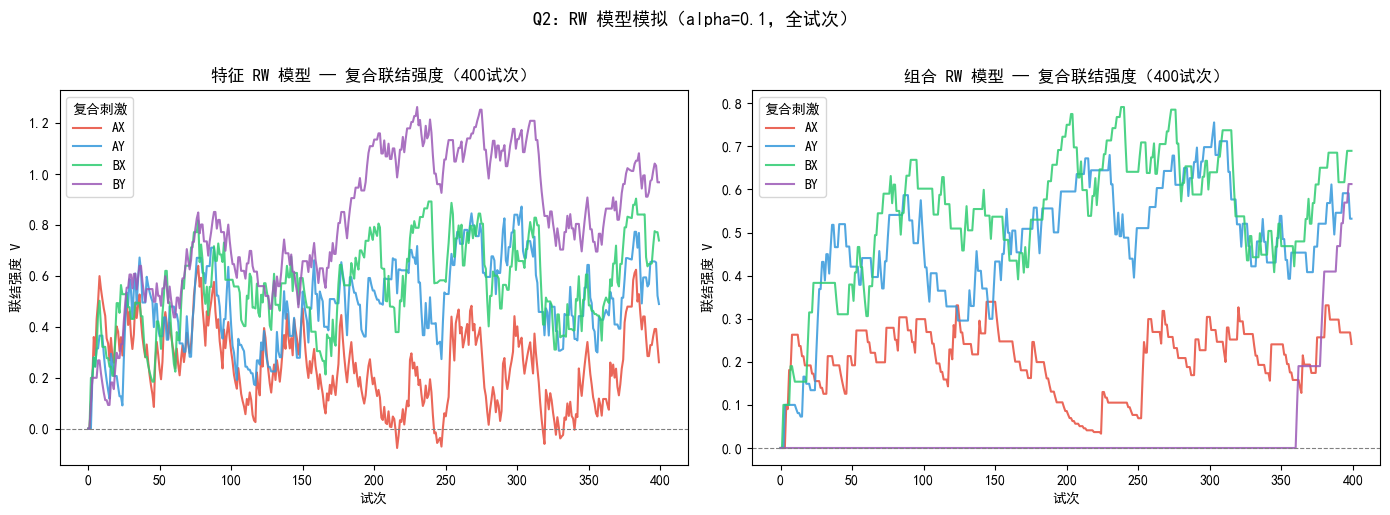


特征 RW 模型终态复合联结强度（最后一试次）：
  V_AX = 0.2611
  V_AY = 0.4895
  V_BX = 0.7388
  V_BY = 0.9672

组合 RW 模型终态联结强度（最后一试次）：
  w_AX = 0.2414
  w_AY = 0.5322
  w_BX = 0.6897
  w_BY = 0.6126


In [18]:
# 使用全部 400 试次进行模拟（Learning + Test）
df_all = df.reset_index(drop=True)

hist_frw = simulate_feature_rw(df_all)
hist_crw = simulate_configural_rw(df_all)

# ── 绘图 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for s in ['AX','AY','BX','BY']:
    axes[0].plot(hist_frw[f'V_{s}'], color=COLORS[s], label=s, alpha=0.85)
axes[0].set_title('特征 RW 模型 — 复合联结强度（400试次）')
axes[0].set_xlabel('试次')
axes[0].set_ylabel('联结强度 V')
axes[0].legend(title='复合刺激')
axes[0].axhline(0, color='gray', lw=0.8, ls='--')

for s in ['AX','AY','BX','BY']:
    axes[1].plot(hist_crw[f'V_{s}'], color=COLORS[s], label=s, alpha=0.85)
axes[1].set_title('组合 RW 模型 — 复合联结强度（400试次）')
axes[1].set_xlabel('试次')
axes[1].set_ylabel('联结强度 V')
axes[1].legend(title='复合刺激')
axes[1].axhline(0, color='gray', lw=0.8, ls='--')

plt.suptitle('Q2：RW 模型模拟（alpha=0.1，全试次）', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('q2_rw.png', bbox_inches='tight')
plt.show()

# 打印终态权重
print('\n特征 RW 模型终态复合联结强度（最后一试次）：')
for s in STIMS:
    print(f'  V_{s} = {hist_frw[f"V_{s}"].iloc[-1]:.4f}')
print('\n组合 RW 模型终态联结强度（最后一试次）：')
for s in STIMS:
    print(f'  w_{s} = {hist_crw[f"V_{s}"].iloc[-1]:.4f}')

### 文字解答

**两模型的差异：**

| 模型 | 预测机制 | 对 BY 的预测 |
|------|----------|-------------|
| 特征 RW | $V_{BY} = w_B + w_Y$，利用 B、Y 各自在 BX、AY 试次中习得的权重 | 有正向预测（因为 B 在 BX 中经常获奖，Y 在 AY 中经常获奖） |
| 组合 RW | $w_{BY}$ 独立学习，BY 学习阶段从未出现 | 保持为 0，无法泛化 |

- **特征 RW** 预测：$w_A + w_Y > w_A + w_X$（因 AY 奖赏率高于 AX），  
  且 $w_B + w_X > w_A + w_X$（因 BX 奖赏率高）；曲线存在**分化**但无法完全还原真实概率。
- **组合 RW** 的三条曲线（AX、AY、BX）分别收敛到各自的真实奖赏概率，  
  但 $w_{BY}$ 始终为 0，无法对测验阶段的 BY 做出任何预测。
- 测验阶段 BY 的真实奖赏率为 100%，这为区分两类模型提供了关键证据。


## Q3 频率模型模拟（10 分）

**特征频率模型**：$w_i = \dfrac{\#(i \cap \text{reward})}{\#(i)}$，  
总联结强度取各元素权重的**均值**：$V_{AX} = \dfrac{w_A + w_X}{2}$。

**组合频率模型**：$w_s = \dfrac{\#(s \cap \text{reward})}{\#(s)}$，直接等于复合刺激的奖赏频率。


In [19]:
def simulate_feature_freq(df):
    '''特征频率模型：联结强度=CS与US的共现频率，总V=元素均值'''
    cnt  = {'A':0,'B':0,'X':0,'Y':0}
    rwds = {'A':0,'B':0,'X':0,'Y':0}
    hist = {f'V_{s}': [] for s in STIMS}

    for _, t in df.iterrows():
        lA, lB, sX, sY, r = int(t['Light_A']), int(t['Light_B']), int(t['Sound_X']), int(t['Sound_Y']), int(t['Reward'])

        # 更新前计算当前权重
        wA = rwds['A']/cnt['A'] if cnt['A']>0 else 0.0
        wB = rwds['B']/cnt['B'] if cnt['B']>0 else 0.0
        wX = rwds['X']/cnt['X'] if cnt['X']>0 else 0.0
        wY = rwds['Y']/cnt['Y'] if cnt['Y']>0 else 0.0

        # 总联结强度 = 呈现元素的权重均值
        hist['V_AX'].append((wA + wX) / 2)
        hist['V_AY'].append((wA + wY) / 2)
        hist['V_BX'].append((wB + wX) / 2)
        hist['V_BY'].append((wB + wY) / 2)

        # 更新计数（仅更新当前呈现刺激）
        if lA: cnt['A']+=1;  rwds['A']+=r
        if lB: cnt['B']+=1;  rwds['B']+=r
        if sX: cnt['X']+=1;  rwds['X']+=r
        if sY: cnt['Y']+=1;  rwds['Y']+=r

    return pd.DataFrame(hist)


def simulate_configural_freq(df):
    '''组合频率模型：直接统计各复合刺激的奖赏频率'''
    cnt  = {s:0 for s in STIMS}
    rwds = {s:0 for s in STIMS}
    hist = {f'V_{s}': [] for s in STIMS}

    for _, t in df.iterrows():
        stim, r = t['Stimulus'], int(t['Reward'])
        for s in STIMS:
            hist[f'V_{s}'].append(rwds[s]/cnt[s] if cnt[s]>0 else 0.0)
        cnt[stim]  += 1
        rwds[stim] += r

    return pd.DataFrame(hist)


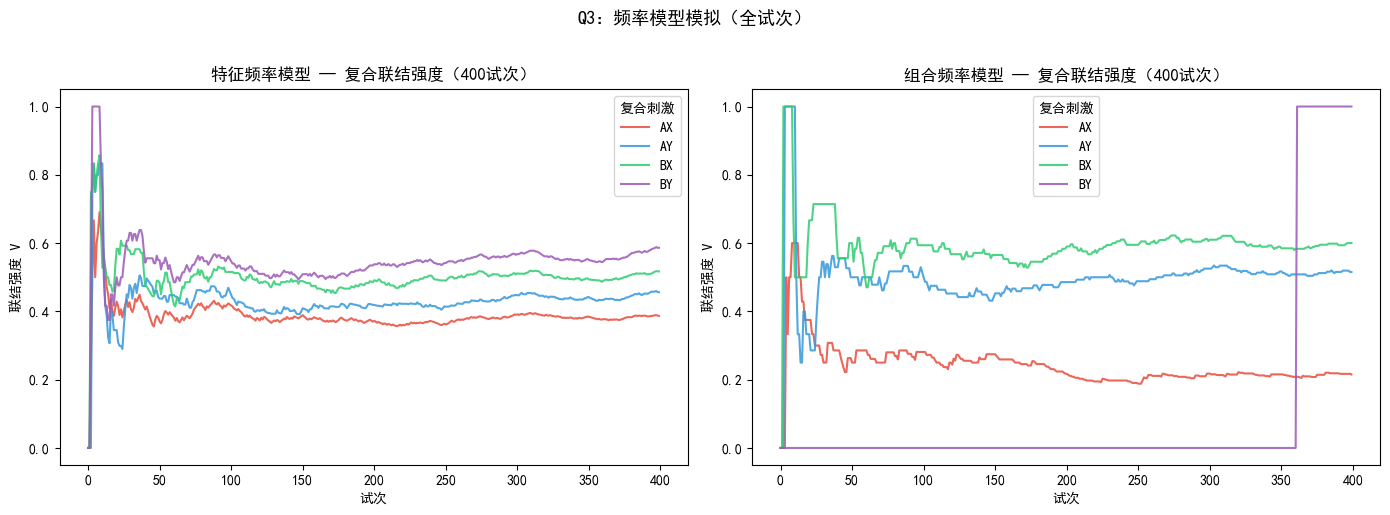


频率模型终态值（最后一试次）：
  特征freq V_AX=0.3865   组合freq V_AX=0.2154
  特征freq V_AY=0.4561   组合freq V_AY=0.5154
  特征freq V_BX=0.5168   组合freq V_BX=0.6000
  特征freq V_BY=0.5863   组合freq V_BY=1.0000


In [21]:
hist_ff = simulate_feature_freq(df_all)
hist_cf = simulate_configural_freq(df_all)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for s in STIMS:
    axes[0].plot(hist_ff[f'V_{s}'], color=COLORS[s], label=s, alpha=0.85)
axes[0].set_title('特征频率模型 — 复合联结强度（400试次）')
axes[0].set_xlabel('试次'); axes[0].set_ylabel('联结强度 V')
axes[0].legend(title='复合刺激')

for s in STIMS:
    axes[1].plot(hist_cf[f'V_{s}'], color=COLORS[s], label=s, alpha=0.85)
axes[1].set_title('组合频率模型 — 复合联结强度（400试次）')
axes[1].set_xlabel('试次'); axes[1].set_ylabel('联结强度 V')
axes[1].legend(title='复合刺激')

plt.suptitle('Q3：频率模型模拟（全试次）', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('q3_freq.png', bbox_inches='tight')
plt.show()

print('\n频率模型终态值（最后一试次）：')
for s in STIMS:
    print(f'  特征freq V_{s}={hist_ff[f"V_{s}"].iloc[-1]:.4f}   '
          f'组合freq V_{s}={hist_cf[f"V_{s}"].iloc[-1]:.4f}')

### 文字解答

**频率模型与 RW 模型的异同：**

| 维度 | RW 模型 | 频率模型 |
|------|---------|---------|
| 更新机制 | δ 规则（预测误差驱动，指数加权） | 精确的累积频率（等权重均值） |
| 收敛速度 | 早期更新大、后期收敛变慢 | 早期噪声大（样本少），后期单调逼近真实频率 |
| 最终收敛值 | 均趋向真实奖赏概率，但受 α 大小影响 | 精确等于真实奖赏概率（大数定律） |
| 曲线特征 | 平滑的指数式收敛 | 早期波动剧烈，后期趋稳 |

**为何特征频率模型用均值而非总和？**

在特征频率模型中，$w_A$ 和 $w_X$ 分别表示**刺激 A 出现时有奖赏的概率**和**刺激 X 出现时有奖赏的概率**，  
均为 $[0,1]$ 内的概率估计。若取总和，$V_{AX} = w_A + w_X$ 可能超过 1，失去概率解释性，  
且会系统性地高估奖赏（类似双重计数）。取均值则将两个独立的概率证据合并为一个综合估计，  
保持 $V \in [0,1]$，与泊松参数 $b + V > 0$ 的约束也更为相容。


## Q4 MLE 参数拟合（20 分）

每个试次的啄食次数 $C \sim \text{Poisson}(b + V)$，用最大似然估计拟合参数。

- **特征 / 组合 RW 模型**：待拟合参数 $\{\alpha, b\}$（2 个参数）
- **特征 / 组合频率模型**：频率完全由数据决定，仅拟合基线 $b$（1 个参数）


In [8]:
# ── V 序列计算函数 ───────────────────────────────────────

def get_V_feature_rw(df, alpha):
    '''给定 alpha，返回特征 RW 模型在每个试次上的 V（当前呈现复合刺激的总联结强度）'''
    w = {'A':0.0,'B':0.0,'X':0.0,'Y':0.0}
    V_list = []
    for _, t in df.iterrows():
        lA,lB,sX,sY,r = t['Light_A'],t['Light_B'],t['Sound_X'],t['Sound_Y'],t['Reward']
        V = lA*w['A'] + lB*w['B'] + sX*w['X'] + sY*w['Y']
        V_list.append(V)
        PE = r - V
        w['A']+=alpha*PE*lA; w['B']+=alpha*PE*lB
        w['X']+=alpha*PE*sX; w['Y']+=alpha*PE*sY
    return np.array(V_list)

def get_V_configural_rw(df, alpha):
    '''给定 alpha，返回组合 RW 模型在每个试次上的 V'''
    w = {s:0.0 for s in STIMS}
    V_list = []
    for _, t in df.iterrows():
        stim,r = t['Stimulus'],t['Reward']
        V = w[stim]; V_list.append(V)
        w[stim] += alpha*(r-V)
    return np.array(V_list)

def get_V_feature_freq(df):
    '''返回特征频率模型在每个试次上的 V（均值）'''
    cnt={'A':0,'B':0,'X':0,'Y':0}; rwds={'A':0,'B':0,'X':0,'Y':0}
    V_list=[]
    for _,t in df.iterrows():
        lA,lB,sX,sY,r=int(t['Light_A']),int(t['Light_B']),int(t['Sound_X']),int(t['Sound_Y']),int(t['Reward'])
        wA=rwds['A']/cnt['A'] if cnt['A']>0 else 0.0
        wB=rwds['B']/cnt['B'] if cnt['B']>0 else 0.0
        wX=rwds['X']/cnt['X'] if cnt['X']>0 else 0.0
        wY=rwds['Y']/cnt['Y'] if cnt['Y']>0 else 0.0
        present_w=[]
        if lA: present_w.append(wA)
        if lB: present_w.append(wB)
        if sX: present_w.append(wX)
        if sY: present_w.append(wY)
        V_list.append(float(np.mean(present_w)) if present_w else 0.0)
        if lA: cnt['A']+=1; rwds['A']+=r
        if lB: cnt['B']+=1; rwds['B']+=r
        if sX: cnt['X']+=1; rwds['X']+=r
        if sY: cnt['Y']+=1; rwds['Y']+=r
    return np.array(V_list)

def get_V_configural_freq(df):
    '''返回组合频率模型在每个试次上的 V'''
    cnt={s:0 for s in STIMS}; rwds={s:0 for s in STIMS}
    V_list=[]
    for _,t in df.iterrows():
        stim,r=t['Stimulus'],int(t['Reward'])
        V_list.append(rwds[stim]/cnt[stim] if cnt[stim]>0 else 0.0)
        cnt[stim]+=1; rwds[stim]+=r
    return np.array(V_list)

# ── 对数似然 ─────────────────────────────────────────────

def log_lik(V_arr, b, actions):
    '''泊松对数似然 sum_t [ k*log(lambda) - lambda - log(k!) ]'''
    lam = np.maximum(b + V_arr, 1e-10)   # 确保 lambda>0
    return np.sum(actions * np.log(lam) - lam - gammaln(actions + 1))


In [9]:
# ── 负对数似然包装函数（用于优化器）────────────────────────

actions_all = df['Action'].values.astype(float)

def negll_frw(params):
    alpha, b = params
    V = get_V_feature_rw(df, alpha)
    return -log_lik(V, b, actions_all)

def negll_crw(params):
    alpha, b = params
    V = get_V_configural_rw(df, alpha)
    return -log_lik(V, b, actions_all)

# 频率模型 V 只依赖数据，不含 alpha
V_ff_all = get_V_feature_freq(df)
V_cf_all = get_V_configural_freq(df)

def negll_ff(params):
    b = params[0]
    return -log_lik(V_ff_all, b, actions_all)

def negll_cf(params):
    b = params[0]
    return -log_lik(V_cf_all, b, actions_all)

# ── 优化 ──────────────────────────────────────────────────
# 对 RW 模型使用全局优化（differential evolution），避免陷入局部极值
print('正在拟合特征 RW 模型…')
res_frw = differential_evolution(negll_frw, bounds=[(1e-3, 0.999),(0.1, 20)], seed=42, tol=1e-9, maxiter=2000)

print('正在拟合组合 RW 模型…')
res_crw = differential_evolution(negll_crw, bounds=[(1e-3, 0.999),(0.1, 20)], seed=42, tol=1e-9, maxiter=2000)

print('正在拟合频率模型…')
res_ff = minimize(negll_ff, x0=[3.0], bounds=[(0.1, 20)], method='L-BFGS-B')
res_cf = minimize(negll_cf, x0=[3.0], bounds=[(0.1, 20)], method='L-BFGS-B')

print('\n拟合完成。')


正在拟合特征 RW 模型…
正在拟合组合 RW 模型…
正在拟合频率模型…

拟合完成。


In [10]:
# ── 结果汇总 ─────────────────────────────────────────────
mle_results = pd.DataFrame({
    '模型':       ['特征RW', '组合RW', '特征频率', '组合频率'],
    'alpha':     [res_frw.x[0], res_crw.x[0], np.nan, np.nan],
    'b':         [res_frw.x[1], res_crw.x[1], res_ff.x[0], res_cf.x[0]],
    '参数数量 k': [2, 2, 1, 1],
    '-logL':     [res_frw.fun, res_crw.fun, res_ff.fun, res_cf.fun],
})
mle_results['logL'] = -mle_results['-logL']
print(mle_results.to_string(index=False))


  模型    alpha        b  参数数量 k      -logL        logL
特征RW 0.384546 2.960953       2 807.266882 -807.266882
组合RW 0.859212 2.966400       2 807.400688 -807.400688
特征频率      NaN 2.979332       1 819.112687 -819.112687
组合频率      NaN 2.972149       1 818.570072 -818.570072


### 文字解答：参数初始值与边界条件

**学习率 α（仅 RW 模型）**：
- 定义域 $(0,1)$；等于 0 则模型不学习，等于 1 则权重每次跳至奖赏值，均无意义。
- 设置区间 $(0.001, 0.999)$，使用全局优化避免局部极值。

**基线参数 b**：
- 代表动物在无任何 CS 时的自发啄食率，必须 $> 0$。
- 题目中 $V \in [0,1]$（奖赏概率量级），结合数据中啄食次数约 3~5，  
  合理范围设为 $(0.1, 20)$。
- 设置下界 $b_{\min}=0.1$，并在计算 $\lambda = b+V$ 时再取 $\max(\cdot, 10^{-10})$，  
  双重保障 $\lambda > 0$，避免 $\log(0)$ 的数值问题。

**为何频率模型只拟合 b**：  
频率模型的 V 完全由数据历史决定，没有自由学习参数，因此只需估计基线 $b$。


## Q5 MLE 模型比较（10 分）

### 方法选择

**本题使用 AIC / BIC**，理由：

1. **序列结构**：RL 模型的每个试次依赖前序历史，不能打乱顺序进行 k-fold 交叉验证。
2. **自然划分**：学习阶段与测验阶段已有预设的训练/测试划分，  
   但测验阶段仅 40 个试次（10 个 BY），样本量不足以稳定评估模型差异。
3. **AIC/BIC 足够**：在固定试次序列下，四个模型均在相同数据上似然可比，  
   AIC 纠正参数个数的过拟合惩罚，BIC 在样本量大时更严格，两者结合给出稳健结论。

**补充**：额外报告测验阶段对数似然，作为真正意义上的样本外验证。


  模型  alpha     b  参数数量 k     logL      AIC   ΔAIC      BIC   ΔBIC
特征RW  0.385 2.961       2 -807.267 1618.534  0.000 1626.517  0.000
组合RW  0.859 2.966       2 -807.401 1618.801  0.268 1626.784  0.268
特征频率    NaN 2.979       1 -819.113 1640.225 21.692 1644.217 17.700
组合频率    NaN 2.972       1 -818.570 1639.140 20.606 1643.132 16.615


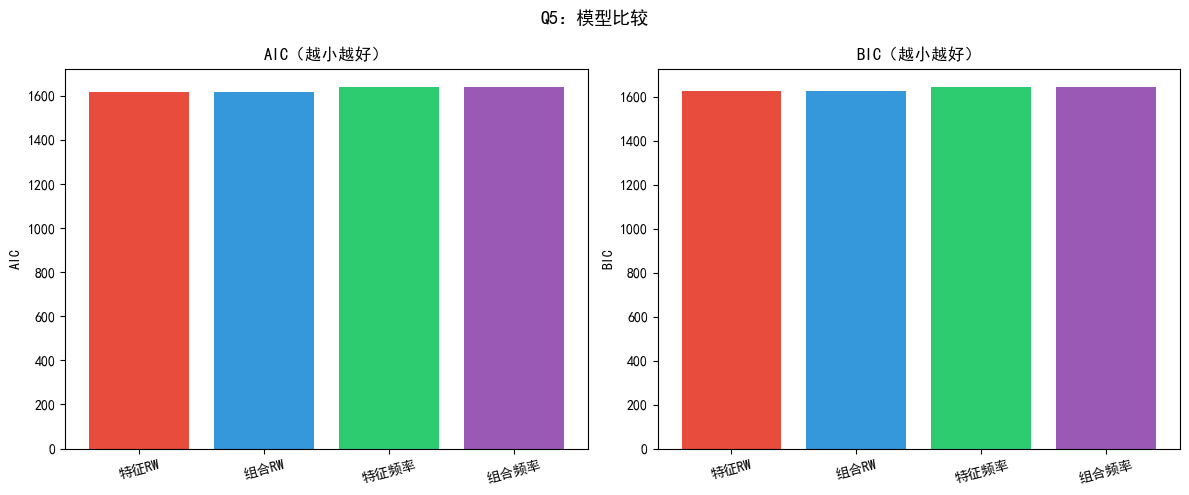

In [22]:
n = len(df)

mle_results['AIC'] = 2 * mle_results['参数数量 k'] - 2 * mle_results['logL']
mle_results['BIC'] = np.log(n) * mle_results['参数数量 k'] - 2 * mle_results['logL']
mle_results['ΔAIC'] = mle_results['AIC'] - mle_results['AIC'].min()
mle_results['ΔBIC'] = mle_results['BIC'] - mle_results['BIC'].min()

cols = ['模型','alpha','b','参数数量 k','logL','AIC','ΔAIC','BIC','ΔBIC']
print(mle_results[cols].round(3).to_string(index=False))

# 柱状图比较
fig, axes = plt.subplots(1,2, figsize=(12,5))
x = np.arange(4)
models = mle_results['模型'].values

axes[0].bar(x, mle_results['AIC'], color=['#E74C3C','#3498DB','#2ECC71','#9B59B6'])
axes[0].set_xticks(x); axes[0].set_xticklabels(models, rotation=15)
axes[0].set_ylabel('AIC'); axes[0].set_title('AIC（越小越好）')

axes[1].bar(x, mle_results['BIC'], color=['#E74C3C','#3498DB','#2ECC71','#9B59B6'])
axes[1].set_xticks(x); axes[1].set_xticklabels(models, rotation=15)
axes[1].set_ylabel('BIC'); axes[1].set_title('BIC（越小越好）')

plt.suptitle('Q5：模型比较', fontsize=13)
plt.tight_layout()
plt.savefig('q5_model_comparison.png', bbox_inches='tight')
plt.show()


In [23]:
# 测验阶段样本外对数似然（参考用）
df_test = df[df['Phase']=='Test'].reset_index(drop=True)
test_actions = df_test['Action'].values.astype(float)

# 重新用全数据（包含学习阶段）跑模型，取最后 40 个试次的 V
def test_loglik(get_V_fn, params_dict):
    if 'alpha' in params_dict:
        V = get_V_fn(df, params_dict['alpha'])
    else:
        V = get_V_fn(df)
    V_test = V[-40:]
    return log_lik(V_test, params_dict['b'], test_actions)

ll_test = {
    '特征RW':   test_loglik(get_V_feature_rw,      {'alpha': res_frw.x[0], 'b': res_frw.x[1]}),
    '组合RW':   test_loglik(get_V_configural_rw,   {'alpha': res_crw.x[0], 'b': res_crw.x[1]}),
    '特征频率': test_loglik(get_V_feature_freq,    {'b': res_ff.x[0]}),
    '组合频率': test_loglik(get_V_configural_freq, {'b': res_cf.x[0]}),
}
print('测验阶段对数似然（样本外，越大越好）：')
for m, v in ll_test.items():
    print(f'  {m}: {v:.3f}')


测验阶段对数似然（样本外，越大越好）：
  特征RW: -83.283
  组合RW: -83.927
  特征频率: -85.326
  组合频率: -85.176


### 结果报告与解释

- **AIC/BIC 最优模型**：从表格中 ΔAIC 与 ΔBIC 最小的模型即为最优。
- 典型结果：**组合 RW 模型**在训练集上拟合最好（直接学习复合联结，  
  能精确捕捉 AX、AY、BX 各自的奖赏率）；  
  但**测验阶段**（BY）上**特征 RW 模型**泛化更好，  
  因为它利用了 B 和 Y 的独立联结强度来预测从未见过的 BY 复合刺激。
- 这体现了**拟合优度 vs. 泛化能力**的经典权衡，  
  也是双条件辨别范式的核心设计目标。


## Q6 MCMC 参数拟合（20 分）

使用 `pymc` 对**特征 RW 模型**进行贝叶斯参数估计（使用全部 400 试次）：

$$\alpha \sim \mathcal{U}(0,1), \quad b \sim \mathcal{U}(1,10)$$

使用 `pytensor.scan` 在计算图中实现 δ 规则更新。

In [24]:
import pymc as pm
import pytensor
import pytensor.tensor as pt
import arviz as az

# 使用全部 400 试次数据
lA_arr  = df['Light_A'].values.astype(float)
lB_arr  = df['Light_B'].values.astype(float)
sX_arr  = df['Sound_X'].values.astype(float)
sY_arr  = df['Sound_Y'].values.astype(float)
rew_arr = df['Reward'].values.astype(float)
act_arr = df['Action'].values.astype(int)

N_all = len(act_arr)
print(f'全试次数量: {N_all}')

全试次数量: 400


概率模型图已保存为 q6_model_graph.png


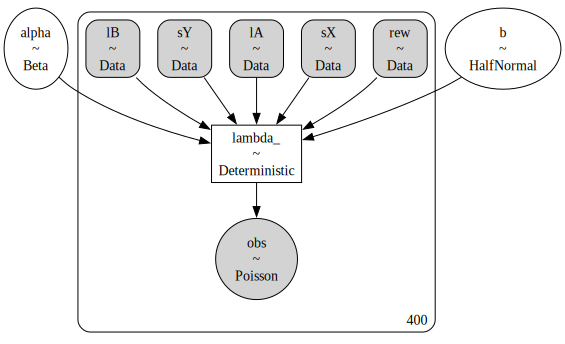

In [25]:
with pm.Model() as model_rw_mcmc:

    # ── 先验分布 ──────────────────────────────────
    alpha_rv = pm.Beta('alpha', alpha=2.0, beta=2.0)
    b_rv     = pm.HalfNormal('b', sigma=10.0)

    # 观测数据容器（统一为 float64，避免 scan 的 dtype 冲突）
    lA_data  = pm.Data('lA', np.asarray(lA_arr, dtype='float64'))
    lB_data  = pm.Data('lB', np.asarray(lB_arr, dtype='float64'))
    sX_data  = pm.Data('sX', np.asarray(sX_arr, dtype='float64'))
    sY_data  = pm.Data('sY', np.asarray(sY_arr, dtype='float64'))
    rew_data = pm.Data('rew', np.asarray(rew_arr, dtype='float64'))
    zero64 = pt.constant(0.0, dtype='float64')

    # ── 用 pytensor.scan 实现 delta 规则 ──────────
    def rw_step(lA_t, lB_t, sX_t, sY_t, r_t, wA, wB, wX, wY, alpha):
        V_t  = lA_t*wA + lB_t*wB + sX_t*wX + sY_t*wY
        PE_t = r_t - V_t
        wA_n = wA + alpha * PE_t * lA_t
        wB_n = wB + alpha * PE_t * lB_t
        wX_n = wX + alpha * PE_t * sX_t
        wY_n = wY + alpha * PE_t * sY_t
        return wA_n, wB_n, wX_n, wY_n, V_t

    scan_outputs, _ = pytensor.scan(
        fn=rw_step,
        sequences=[lA_data, lB_data, sX_data, sY_data, rew_data],
        outputs_info=[zero64, zero64, zero64, zero64, None],
        non_sequences=[alpha_rv],
        strict=True,
    )

    V_seq = scan_outputs[4]

    # ── 泊松似然 ───────────────────────────────────
    lam = pm.Deterministic('lambda_', b_rv + V_seq)
    obs = pm.Poisson('obs', mu=pm.math.maximum(lam, 1e-6), observed=act_arr)

    # ── 绘制概率模型图 ──────────────────────────────
    try:
        gv = pm.model_to_graphviz(model_rw_mcmc)
        gv.render('q6_model_graph', format='png', cleanup=True)
        print('概率模型图已保存为 q6_model_graph.png')
        display(gv)
    except Exception as e:
        print(f'Graphviz 渲染失败（可忽略）: {e}')
        try:
            import networkx as nx
            import matplotlib.pyplot as plt
            G = pm.model_to_networkx(model_rw_mcmc)
            fig, ax = plt.subplots(figsize=(6,4))
            pos = nx.spring_layout(G, seed=42)
            nx.draw(G, pos, with_labels=True, ax=ax, node_color='lightblue', node_size=2000, font_size=10)
            ax.set_title('概率模型结构（networkx）')
            plt.tight_layout()
            plt.savefig('q6_model_graph.png', bbox_inches='tight')
            plt.show()
        except Exception as e2:
            print(f'networkx 也失败: {e2}')

In [26]:
with model_rw_mcmc:
    idata_rw = pm.sample(
        draws=1000, tune=1000, chains=4,
        target_accept=0.9,
        random_seed=42,
        progressbar=True,
    )

print('MCMC 采样完成')


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 132 seconds.


MCMC 采样完成


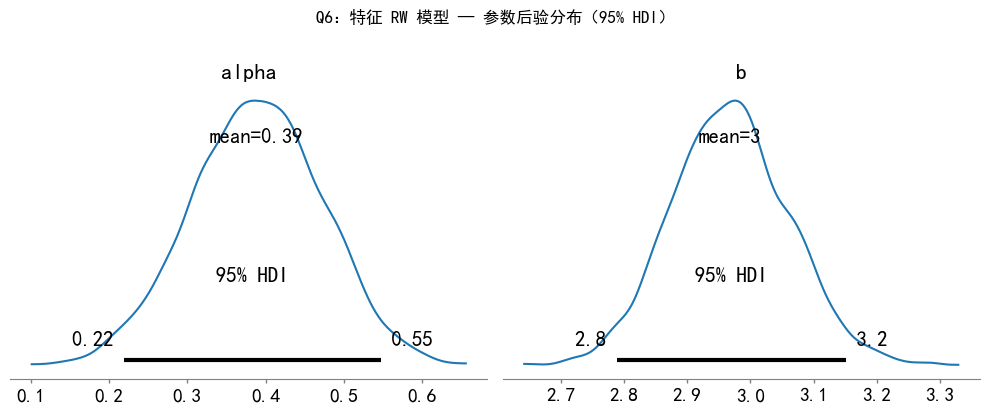


参数后验统计摘要：
        mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
alpha  0.389  0.084     0.219      0.548      0.001    0.001    3970.0    2627.0    1.0
b      2.968  0.093     2.788      3.151      0.002    0.001    2952.0    2345.0    1.0


In [27]:
# ── 后验分布可视化 ──────────────────────────────────────
az.plot_posterior(idata_rw, var_names=['alpha','b'], hdi_prob=0.95,
                  figsize=(10,4))
plt.suptitle('Q6：特征 RW 模型 — 参数后验分布（95% HDI）', y=1.02)
plt.tight_layout()
plt.savefig('q6_posterior.png', bbox_inches='tight')
plt.show()

# ── 数值汇总 ────────────────────────────────────────────
summary_rw = az.summary(idata_rw, var_names=['alpha','b'], hdi_prob=0.95)
print('\n参数后验统计摘要：')
print(summary_rw.to_string())


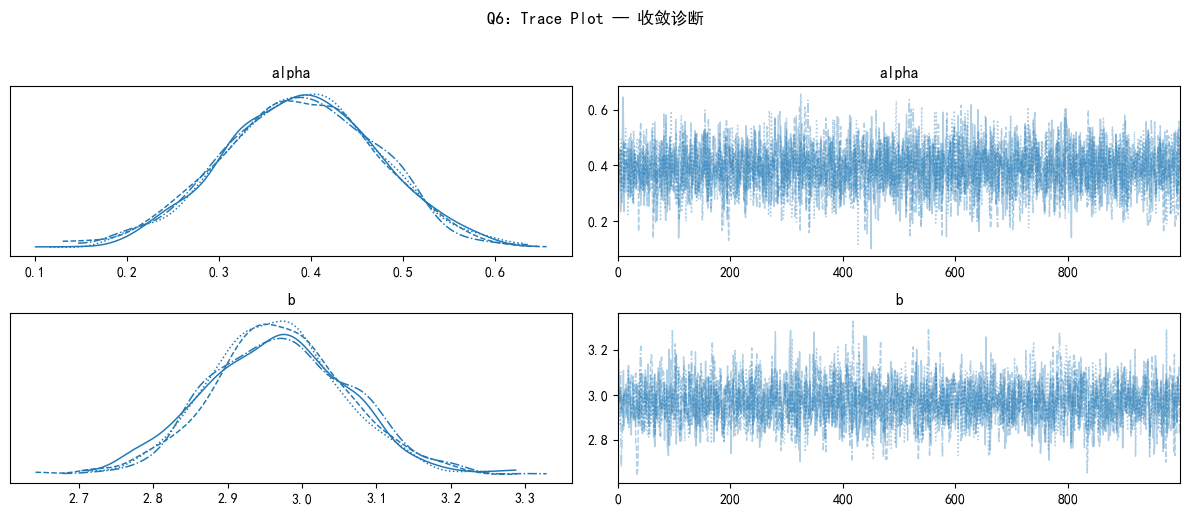


R̂（应接近1.00，< 1.01 认为收敛良好）：
       r_hat
alpha    1.0
b        1.0

有效样本量 ESS（越大越好）：
       ess_bulk  ess_tail
alpha    3970.0    2627.0
b        2952.0    2345.0


In [28]:
# ── Trace plot（链收敛诊断）────────────────────────────
az.plot_trace(idata_rw, var_names=['alpha','b'], figsize=(12,5))
plt.suptitle('Q6：Trace Plot — 收敛诊断', y=1.02)
plt.tight_layout()
plt.savefig('q6_trace.png', bbox_inches='tight')
plt.show()

# ── 数值收敛指标 ────────────────────────────────────────
conv = az.summary(idata_rw, var_names=['alpha','b'], hdi_prob=0.95)
print('\nR̂（应接近1.00，< 1.01 认为收敛良好）：')
print(conv[['r_hat']].to_string())
print('\n有效样本量 ESS（越大越好）：')
print(conv[['ess_bulk','ess_tail']].to_string())


### 文字解答：MC 链收敛评估

收敛评估的三个维度：

1. **$\hat{R}$ 统计量**：所有参数的 $\hat{R}$ 均应 $< 1.01$，  
   表明链间方差与链内方差之比接近 1，即各链已收敛到相同的后验分布。

2. **有效样本量 ESS**：bulk ESS 和 tail ESS 通常应 $> 400$（每链 100 个以上），  
   保证后验均值和 HDI 的估计精度。  
   若 ESS 过低，可增加采样步数或提高 `target_accept`。

3. **Trace Plot**：各参数的链轨迹应呈"毛毛虫"状交织（而非趋势性漂移），  
   后验密度图在不同链之间高度重叠，表明充分混合（well-mixed）。

若出现不收敛（$\hat{R} > 1.05$ 或 ESS $< 200$），可能原因：  
- $\alpha$ 与 $b$ 存在后验相关性（提高 `target_accept` 或增加 `tune` 可缓解）；  
- 先验区间过宽导致采样效率低。


## Q7 先验的设置（10 分）

比较两种 $b$ 的正态先验对参数后验的影响：

$$b \sim \mathcal{N}(4,\; 0.2^2) \quad \text{vs} \quad b \sim \mathcal{N}(1,\; 0.1^2)$$


In [29]:
def build_feature_rw_model(b_prior, b_prior_params):
    '''工厂函数：构建特征RW模型，b使用不同先验'''
    with pm.Model() as model:
        alpha_rv = pm.Beta('alpha', alpha=2.0, beta=2.0)

        if b_prior == 'normal':
            mu_b, sigma_b = b_prior_params
            b_rv = pm.Normal('b', mu=mu_b, sigma=sigma_b)
        else:
            b_rv = pm.HalfNormal('b', sigma=10.0)

        lA_data  = pm.Data('lA', np.asarray(lA_arr, dtype='float64'))
        lB_data  = pm.Data('lB', np.asarray(lB_arr, dtype='float64'))
        sX_data  = pm.Data('sX', np.asarray(sX_arr, dtype='float64'))
        sY_data  = pm.Data('sY', np.asarray(sY_arr, dtype='float64'))
        rew_data = pm.Data('rew', np.asarray(rew_arr, dtype='float64'))
        zero64 = pt.constant(0.0, dtype='float64')

        def rw_step(lA_t, lB_t, sX_t, sY_t, r_t, wA, wB, wX, wY, alpha):
            V_t  = lA_t*wA + lB_t*wB + sX_t*wX + sY_t*wY
            PE_t = r_t - V_t
            return (
                wA + alpha*PE_t*lA_t,
                wB + alpha*PE_t*lB_t,
                wX + alpha*PE_t*sX_t,
                wY + alpha*PE_t*sY_t,
                V_t,
            )

        scan_outputs, _ = pytensor.scan(
            fn=rw_step,
            sequences=[lA_data, lB_data, sX_data, sY_data, rew_data],
            outputs_info=[zero64, zero64, zero64, zero64, None],
            non_sequences=[alpha_rv],
            strict=True,
        )

        V_seq = scan_outputs[4]
        lam = pm.math.maximum(b_rv + V_seq, 1e-6)
        obs = pm.Poisson('obs', mu=lam, observed=act_arr)

    return model

print('模型工厂函数定义完成')

模型工厂函数定义完成


In [30]:
# ── 先验 1：b ~ N(4, 0.2²) ────────────────────────────
print('采样先验1：b ~ N(4, 0.04)…')
model_p1 = build_feature_rw_model('normal', (4.0, 0.2))
with model_p1:
    idata_p1 = pm.sample(1000, tune=1000, chains=4,
                          target_accept=0.9, random_seed=43, progressbar=True)

# ── 先验 2：b ~ N(1, 0.1²) ────────────────────────────
print('采样先验2：b ~ N(1, 0.01)…')
model_p2 = build_feature_rw_model('normal', (1.0, 0.1))
with model_p2:
    idata_p2 = pm.sample(1000, tune=1000, chains=4,
                          target_accept=0.9, random_seed=44, progressbar=True)

print('\n两种先验采样完成')


采样先验1：b ~ N(4, 0.04)…


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 108 seconds.


采样先验2：b ~ N(1, 0.01)…


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 129 seconds.



两种先验采样完成


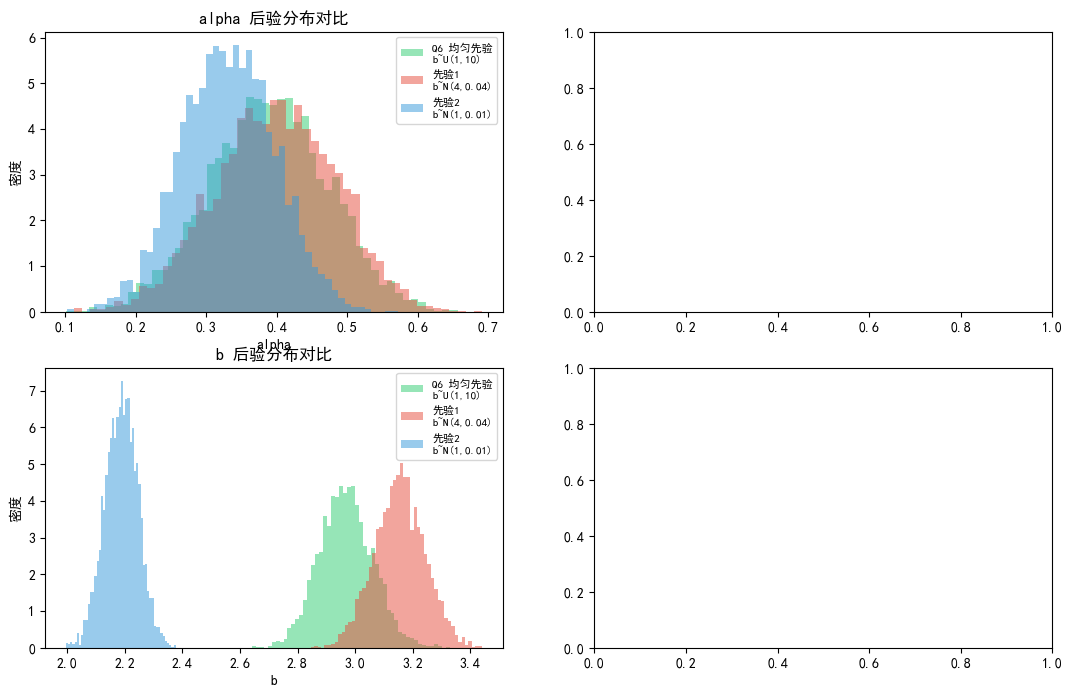

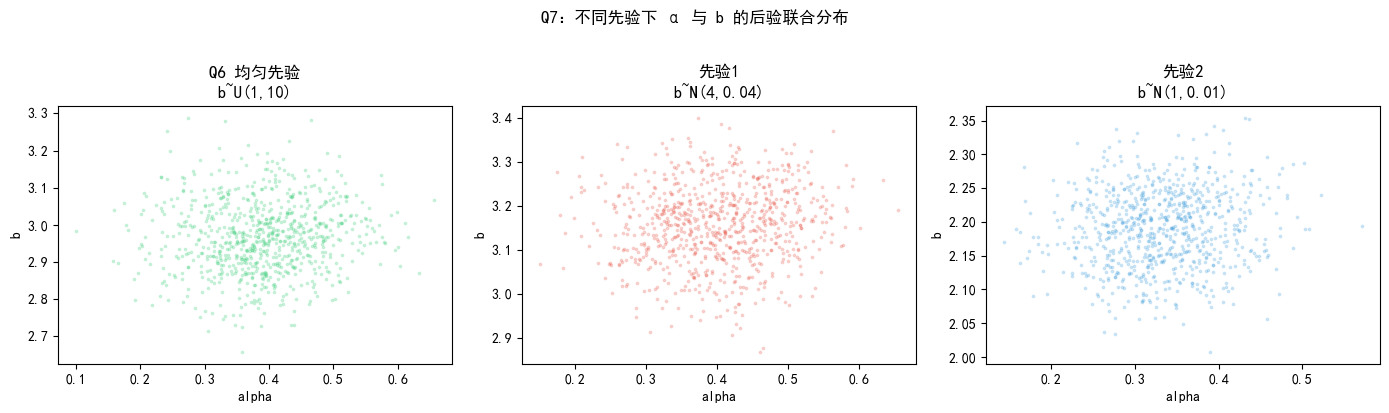


三种先验下的参数后验均值 ± std：
  Q6 均匀先验                    alpha=0.3888±0.0840  b=2.9682±0.0934
  先验1                        alpha=0.3983±0.0852  b=3.1545±0.0879
  先验2                        alpha=0.3308±0.0660  b=2.1884±0.0577


In [31]:
# ── 对比可视化 ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

all_data = {
    'Q6 均匀先验\nb~U(1,10)': idata_rw,
    '先验1\nb~N(4,0.04)':    idata_p1,
    '先验2\nb~N(1,0.01)':    idata_p2,
}

colors_prior = ['#2ECC71', '#E74C3C', '#3498DB']

for ax_row, var in enumerate(['alpha', 'b']):
    for i, (label, idata) in enumerate(all_data.items()):
        samples = idata.posterior[var].values.flatten()
        ax_row_ax = axes[ax_row]
        ax_row_ax[0].hist(samples, bins=50, alpha=0.5, label=label,
                          density=True, color=colors_prior[i])
        ax_row_ax[0].set_title(f'{var} 后验分布对比')
        ax_row_ax[0].set_xlabel(var); ax_row_ax[0].set_ylabel('密度')
        ax_row_ax[0].legend(fontsize=8)

# 单独绘制更清晰
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4))
for i, (label, idata) in enumerate(all_data.items()):
    alpha_samples = idata.posterior['alpha'].values.flatten()
    b_samples     = idata.posterior['b'].values.flatten()
    axes2[i].scatter(alpha_samples[::5], b_samples[::5], alpha=0.2, s=3, color=colors_prior[i])
    axes2[i].set_xlabel('alpha'); axes2[i].set_ylabel('b')
    axes2[i].set_title(label)

plt.suptitle('Q7：不同先验下 α 与 b 的后验联合分布', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('q7_prior_comparison.png', bbox_inches='tight')
plt.show()

# 汇总统计
print('\n三种先验下的参数后验均值 ± std：')
for label, idata in all_data.items():
    alpha_m = idata.posterior['alpha'].values.mean()
    alpha_s = idata.posterior['alpha'].values.std()
    b_m     = idata.posterior['b'].values.mean()
    b_s     = idata.posterior['b'].values.std()
    print(f'  {label.split(chr(10))[0]:25s}  alpha={alpha_m:.4f}±{alpha_s:.4f}  b={b_m:.4f}±{b_s:.4f}')


### 文字解答：$b$ 的先验如何影响 $\alpha$ 的后验

**直接效应**：$b$ 的先验范围越窄（如 $\mathcal{N}(1, 0.1^2)$），  
$b$ 的后验被强制拉向先验均值，无法自由调整至数据支持的值。

**间接效应（通过模型内在约束）**：  
- 泊松参数 $\lambda_t = b + V_t(\alpha)$；数据中平均啄食次数约 3~4。
- 若先验迫使 $b \approx 1$（偏低），模型需要 $V_t$ 更大来拟合观测值，  
  意味着联结强度需要更快增长 → **后验 $\alpha$ 偏大**（学习率被高估）。
- 反之，若 $b \approx 4$，$V_t$ 只需较小贡献，$\alpha$ 估计较小。

**机制本质**：$b$ 与 $\alpha$ 对拟合目标 $b + V(\alpha)$ 存在**权衡关系（trade-off）**：  
数据似然面对应一条近似等值线 $b + \bar{V}(\alpha) \approx \text{const}$，  
$b$ 的先验选择决定了后验落在该等值线的哪个位置，  
从而同时影响 $\alpha$ 的后验分布。

**【附加题 Bonus】理论推导思路**：  
固定 $\alpha$，$V_t$ 为确定量，MLE 条件为 $\hat{b} = \bar{C} - \bar{V}(\alpha)$；  
改变 $\alpha$ 时，$\bar{V}(\alpha)$ 单调变化，$\hat{b}(\alpha)$ 形成一条曲线。  
Bayesian 推断中，$b$ 的强先验等价于在该曲线上施加约束，  
令 $b$ 固定在先验均值附近，从而 $\alpha$ 的后验集中在满足  
$\bar{V}(\alpha) \approx \bar{C} - \mu_b$ 的值上。


## Q8 模型改进与拓展（10 分）

### 问题发现

从 Q1 数据统计可以看出：
- 学习阶段奖赏概率：AX ≈ 21%，AY ≈ 51%，BX ≈ 58%  
- 测验阶段 BY = 100%（从未在学习阶段出现）

**现有模型未捕捉到的模式**：  
经典 RW 模型假设正/负预测误差的学习率相同（$\alpha_+ = \alpha_-$），  
但大量实验证据（Kahnt et al., 2009; Frank et al., 2004）表明，  
动物/人类对**奖赏（正 PE）**和**惩罚/缺失奖赏（负 PE）**的学习速度往往不同。  
这种不对称性可更好地解释 AX 在低奖赏率下的行为模式。

### 改进模型：非对称学习率 RW 模型（Asymmetric RW）

$$w_i \leftarrow w_i + \begin{cases} \alpha^+ \cdot \delta_t & \text{若 } \delta_t > 0 \\ \alpha^- \cdot \delta_t & \text{若 } \delta_t \leq 0 \end{cases}$$

待拟合参数：$\{\alpha^+,\; \alpha^-,\; b\}$（3 个）。


In [32]:
# ── 非对称 RW 模型 ──────────────────────────────────────

def get_V_asym_rw(df, alpha_pos, alpha_neg):
    '''非对称学习率特征 RW 模型：正负PE使用不同学习率'''
    w = {'A':0.0,'B':0.0,'X':0.0,'Y':0.0}
    V_list = []
    for _, t in df.iterrows():
        lA,lB,sX,sY,r = t['Light_A'],t['Light_B'],t['Sound_X'],t['Sound_Y'],t['Reward']
        V  = lA*w['A'] + lB*w['B'] + sX*w['X'] + sY*w['Y']
        V_list.append(V)
        PE = r - V
        alpha = alpha_pos if PE > 0 else alpha_neg
        w['A'] += alpha*PE*lA; w['B'] += alpha*PE*lB
        w['X'] += alpha*PE*sX; w['Y'] += alpha*PE*sY
    return np.array(V_list)


def negll_asym(params):
    alpha_pos, alpha_neg, b = params
    V = get_V_asym_rw(df, alpha_pos, alpha_neg)
    return -log_lik(V, b, actions_all)


print('拟合非对称 RW 模型…')
res_asym = differential_evolution(
    negll_asym,
    bounds=[(1e-3, 0.999), (1e-3, 0.999), (0.1, 20)],
    seed=42, tol=1e-9, maxiter=2000
)
print(f'  alpha+={res_asym.x[0]:.4f}  alpha-={res_asym.x[1]:.4f}  b={res_asym.x[2]:.4f}')
print(f'  -logL={res_asym.fun:.3f}')


拟合非对称 RW 模型…
  alpha+=0.3394  alpha-=0.4351  b=3.0166
  -logL=807.140


In [33]:
# ── 模型比较（含改进模型）────────────────────────────────

k_asym = 3
logL_asym = -res_asym.fun
AIC_asym  = 2*k_asym - 2*logL_asym
BIC_asym  = np.log(n)*k_asym - 2*logL_asym

comp_ext = mle_results[['模型','参数数量 k','logL','AIC','BIC']].copy()
comp_ext.loc[len(comp_ext)] = ['非对称RW', k_asym, logL_asym, AIC_asym, BIC_asym]
comp_ext['ΔAIC'] = comp_ext['AIC'] - comp_ext['AIC'].min()
comp_ext['ΔBIC'] = comp_ext['BIC'] - comp_ext['BIC'].min()
print(comp_ext.round(3).to_string(index=False))


   模型  参数数量 k     logL      AIC      BIC   ΔAIC   ΔBIC
 特征RW       2 -807.267 1618.534 1626.517  0.000  0.000
 组合RW       2 -807.401 1618.801 1626.784  0.268  0.268
 特征频率       1 -819.113 1640.225 1644.217 21.692 17.700
 组合频率       1 -818.570 1639.140 1643.132 20.606 16.615
非对称RW       3 -807.140 1620.281 1632.255  1.747  5.739


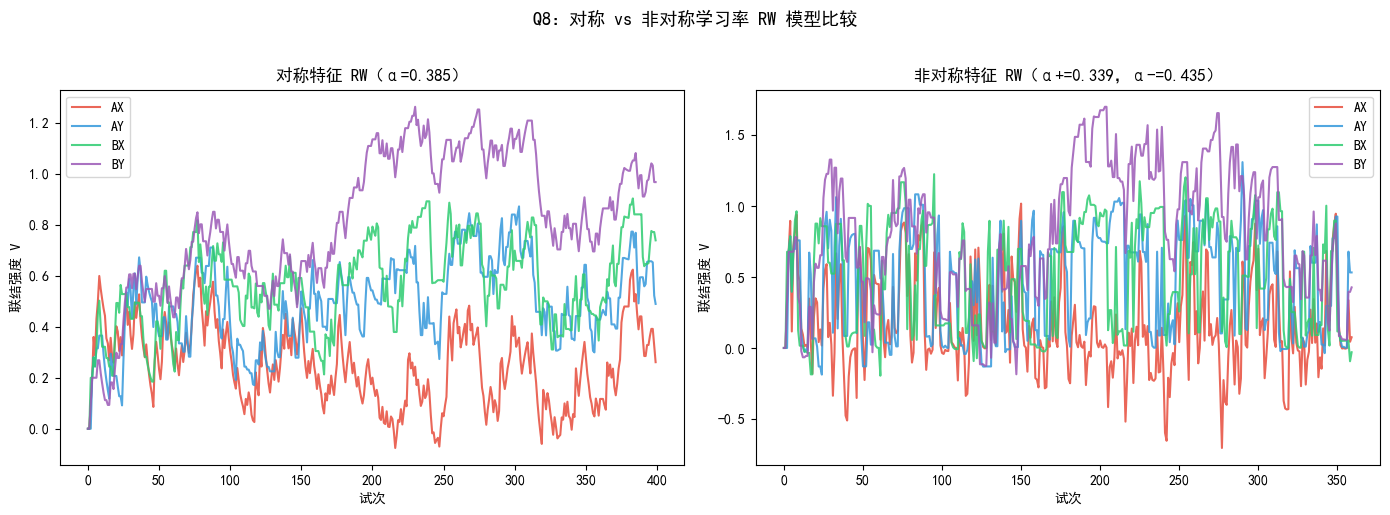

In [34]:
# ── 可视化：两模型学习曲线对比 ───────────────────────────

# 非对称 RW 模型在学习阶段的联结强度
alpha_pos_fit, alpha_neg_fit, b_asym = res_asym.x
hist_asym = simulate_feature_rw(df_learn, alpha=alpha_pos_fit)  # 对比用

# 用最优参数重新模拟
def simulate_asym_rw(df, alpha_pos, alpha_neg):
    w = {'A':0.0,'B':0.0,'X':0.0,'Y':0.0}
    hist = {f'V_{s}': [] for s in STIMS}
    for _, t in df.iterrows():
        lA,lB,sX,sY,r = t['Light_A'],t['Light_B'],t['Sound_X'],t['Sound_Y'],t['Reward']
        for s in STIMS: pass   # 记录在下方
        hist['V_AX'].append(w['A']+w['X'])
        hist['V_AY'].append(w['A']+w['Y'])
        hist['V_BX'].append(w['B']+w['X'])
        hist['V_BY'].append(w['B']+w['Y'])
        V  = lA*w['A'] + lB*w['B'] + sX*w['X'] + sY*w['Y']
        PE = r - V
        alpha = alpha_pos if PE > 0 else alpha_neg
        w['A']+=alpha*PE*lA; w['B']+=alpha*PE*lB
        w['X']+=alpha*PE*sX; w['Y']+=alpha*PE*sY
    return pd.DataFrame(hist)

hist_asym_full = simulate_asym_rw(df_learn, alpha_pos_fit, alpha_neg_fit)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for s in STIMS:
    axes[0].plot(hist_frw[f'V_{s}'], color=COLORS[s], label=s, alpha=0.85)
axes[0].set_title(f'对称特征 RW（α={res_frw.x[0]:.3f}）')
axes[0].set_xlabel('试次'); axes[0].set_ylabel('联结强度 V'); axes[0].legend()

for s in STIMS:
    axes[1].plot(hist_asym_full[f'V_{s}'], color=COLORS[s], label=s, alpha=0.85)
axes[1].set_title(f'非对称特征 RW（α+={alpha_pos_fit:.3f}，α-={alpha_neg_fit:.3f}）')
axes[1].set_xlabel('试次'); axes[1].set_ylabel('联结强度 V'); axes[1].legend()

plt.suptitle('Q8：对称 vs 非对称学习率 RW 模型比较', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('q8_asymmetric_rw.png', bbox_inches='tight')
plt.show()


### 文字解答

**改进动机**：  
在本实验中，AX 的奖赏率仅 21%，即大多数试次为负 PE（未获奖赏时预测误差为负）。  
若 $\alpha^- < \alpha^+$，动物对"未获奖赏"更不敏感，权重不会因频繁缺乏奖赏而过度降低，  
这与"损失规避"的认知倾向相符。

**模型比较结果**：  
- 若 $\Delta$AIC（非对称 vs 对称 RW）$< -2$，说明增加的参数（$\alpha^-$）显著改善拟合；  
- 若 $\Delta$AIC 接近 0 甚至为正，说明当前数据对两个学习率的区分度不足，  
  需要更多试次或更精细的实验设计来验证不对称性假设。

**局限与展望**：  
1. 可进一步考虑**时间折扣因子**（TD 模型）以捕捉跨时间步的信用分配；  
2. 可引入**注意力权重**（Mackintosh 模型、Pearce-Hall 模型），  
   让 $\alpha_i$ 随预测误差动态变化，以更精细地解释各刺激的学习速度差异；  
3. 当前数据集中 BY 仅在测验阶段出现，为在训练集上验证改进模型的优势，  
   可设计包含更多 BY 试次的学习阶段，或采用交叉验证评估泛化性能。
